# COVID-19 Data Exploration

**Group:** A1

**Students:** 
- Chetan Babu Mahendiran
- Micheal Kennedy
- David Compagno
- Shahmeer Khan

This notebook is for the exploration of *country_vaccinations.csv* and *worldometer_data.csv*, uses `pandas`, `matplotlib`, `seaborn` and `numpy` includes type annotations, validation, a custom exception, and demonstrates EDA and hypothesis testing.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
countryDF = pd.read_csv("data/country_vaccinations.csv")
worldDF = pd.read_csv("data/worldometer_data.csv")

In [3]:
display(worldDF.head())
display(worldDF.info())
display(countryDF.head())
display(countryDF.info())

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas,NaN,NaN,NaN
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas,NaN,NaN,NaN
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia,NaN,NaN,NaN
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe,NaN,NaN,NaN
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    object 
 1   Continent         208 non-null    object 
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   NewCases          4 non-null      float64
 5   TotalDeaths       188 non-null    float64
 6   NewDeaths         3 non-null      float64
 7   TotalRecovered    205 non-null    float64
 8   NewRecovered      3 non-null      float64
 9   ActiveCases       205 non-null    float64
 10  Serious,Critical  122 non-null    float64
 11  Tot Cases/1M pop  208 non-null    float64
 12  Deaths/1M pop     187 non-null    float64
 13  TotalTests        191 non-null    float64
 14  Tests/1M pop      191 non-null    float64
 15  WHO Region        184 non-null    object 
 16  Unnamed: 16       0 non-null      float64
 1

None

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,...,daily_vaccinations_per_million,vaccines,source_name,source_website,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,Afghanistan,AFG,2/22/21,0.0,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,2/23/21,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,...,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,2/24/21,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,...,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,2/25/21,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,...,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,2/26/21,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,...,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79486 entries, 0 to 79485
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              79486 non-null  object 
 1   iso_code                             79486 non-null  object 
 2   date                                 79486 non-null  object 
 3   total_vaccinations                   40805 non-null  float64
 4   people_vaccinated                    38664 non-null  float64
 5   people_fully_vaccinated              36210 non-null  float64
 6   daily_vaccinations_raw               33213 non-null  float64
 7   daily_vaccinations                   79173 non-null  float64
 8   total_vaccinations_per_hundred       40805 non-null  float64
 9   people_vaccinated_per_hundred        38664 non-null  float64
 10  people_fully_vaccinated_per_hundred  36210 non-null  float64
 11  daily_vaccinations_per_milli

None

## Data Cleansing Process

Below, we define multiple functions to clean and prepare the two datasets.
Each function includes the following:

- **Docstrings**
- **Annotations**
- **Input/Output validation**
- **Custom exception handling**

All of the above ensures that the code is organised and reusable

#### Custom Exception

In [4]:
class DataValidationError(Exception):
    """
    Custom exception for data validation errors when processing a pandas dataFrame
    """
    pass

#### Custom cleaning functions

In [5]:
def dropCols(dataframe: pd.DataFrame) -> pd.DataFrame:

    """
    Removes columns with more than 20% missing values from the dataframe,
    this action is part of the data cleansing process to reduce noise and incomplete elements
    
    Args: dataframe - A pandas dataframe which will be cleaned.

    Returns: A cleaned version of the input dataframe with columns with more than 20% 
    of missing values removed
    """
    
    if not isinstance(dataframe, pd.DataFrame):
        raise DataValidationError("dropCols: 'dataframe' must be a pandas DataFrame.")
    if dataframe.empty:
        raise DataValidationError("dropCols: input dataframe is empty.")
    threshold = len(dataframe) * 0.20
    cleanedDS = dataframe.dropna(axis=1, thresh=len(dataframe) - threshold)

    if cleanedDS.empty:
        raise DataValidationError("dropCols: all columns were removed; check missing data.")
    
    return cleanedDS


def popDrop(dataFrame: pd.DataFrame) -> pd.DataFrame:
    
    """
    Drop rows where population values are missing.
    Population is necessary for later per-million calculations,
    so rows without population cannot be used adequately

    Args: dataframe - A pandas dataframe which will be cleaned.

    Returns: A cleaned version of the input dataframe with rows where population is 
    missing now removed from the dataframe. 
    """
    
    if not isinstance(dataFrame, pd.DataFrame):
        raise DataValidationError("popDrop: 'dataFrame' must be a pandas DataFrame.")

    if 'Population' not in dataFrame.columns:
        raise DataValidationError("popDrop: expected 'Population' column in dataFrame.")

    cleanedDS = dataFrame.dropna(subset=['Population'])

    if cleanedDS.empty:
        raise DataValidationError("popDrop: all rows removed; no valid population data.")

    return cleanedDS


def seriousNas(dataFrame: pd.DataFrame) -> pd.DataFrame:

    """
    Replace missing values in the Serious and Critical column with 0.
    Many countries report no severe cases, so Na's here are treated as zero 
    to maintain consistency levels in severity analysis

    Args: dataFrame - A pandas dataframe which will be cleaned.

    Returns: A cleaned version of the input dataframe with values of 0 in place
    of Na's in the 'Serious,Critical' column. 
    """

    if not isinstance(dataFrame, pd.DataFrame):
       raise DataValidationError("seriousNas: 'dataFrame' must be a pandas DataFrame.")
    if 'Serious,Critical' not in dataFrame.columns:
       raise DataValidationError("seriousNas: column 'Serious,Critical' is missing.")

    
    dataFrame = dataFrame.copy()
    dataFrame['Serious,Critical'] = dataFrame['Serious,Critical'].fillna(0)
    return dataFrame


def totalVax(dataFrame: pd.DataFrame) -> pd.DataFrame:

    """
    Compute cumulative total vaccinations per country by means of daily counts. 
    This creates a new column which represents daily vaccination rollout progress
    
    Args: dataFrame - A pandas dataframe which will be cleaned.

    Returns: A cleaned version of the input dataframe with the 'totalVaccinations' now
    populated by the sum of the daily vaccinations for each country.
    """

    if not isinstance(dataFrame, pd.DataFrame):
        raise DataValidationError("totalVax: 'dataFrame' must be a pandas DataFrame.")
   
    for col in ['country', 'daily_vaccinations']:
        if col not in dataFrame.columns:
            raise DataValidationError(f"totalVax: required column '{col}' is missing.")
    
    dataFrame['totalVaccinations'] = (dataFrame.groupby("country")['daily_vaccinations'].cumsum())
    return dataFrame


def dropSelectedCol(dataFrame: pd.DataFrame, col: str) -> pd.DataFrame:
    
    """
    Removes a user selected column from the dataframe.
    
    Args: 
        dataFrame - A pandas dataframe which the column will be removed from.
        col - A string of the column name to be removed.

    Returns: A cleaned version of the input dataframe with the selected column 'col' now
    removed from the dataframe.
    """
    
    if col not in dataFrame.columns:
        raise DataValidationError(f"dataFrame: '{col}' missing from input dataframe.")
    else:
        return dataFrame.drop(col, axis=1)

    
def populationCols(dataFrame: pd.DataFrame, populationDF: pd.DataFrame) -> pd.DataFrame:

    """
    Add population values to the vaccination dataFrame by mapping 
    population data from the Worldometer dataFrame using country names.
    
    Args: Two pandas dataframes
    dataFrame: the dataframe which will have the countries population mapped to.
    populationDS: the dataframe which contains the population for each country.

    Returns: A new version of the dataFrame with a population value for each country available in 
    populationDS.

    """

    if not isinstance(dataFrame, pd.DataFrame):
        raise DataValidationError("populationCols: 'dataFrame' must be a pandas DataFrame.")
    if not isinstance(populationDF, pd.DataFrame):
        raise DataValidationError("populationCols: 'populationDF' must be a pandas DataFrame.")

    for col in ['country']:
        if col not in dataFrame.columns:
            raise DataValidationError(f"populationCols: '{col}' column missing in dataFrame.")

    for col in ['Country/Region', 'Population']:
        if col not in populationDF.columns:
            raise DataValidationError(f"populationCols: '{col}' column missing in populationDF.")
    
    population_lookup = populationDF.set_index('Country/Region')['Population'].to_dict()
    dataFrame['Population'] = dataFrame['country'].map(population_lookup)

    if dataFrame['Population'].isna().all():
        raise DataValidationError("populationCols: population mapping failed for all rows.")
    return dataFrame




## Running Data Cleaning with Error Handling

We now insert all cleaning functions inside a `try/except` block.
If inputted data is invalid or vital columns are missing, our customised
`DataValidationError` prevents crashes and provides accurate feedback.

In [6]:
try:
    countryDF = dropCols(countryDF)
    countryDF = dropSelectedCol(countryDF, "source_website")
    countryDF = totalVax(countryDF)
    countryDF = populationCols(countryDF, worldDF)

    worldDF = seriousNas(worldDF)
    worldDF = dropCols(worldDF)
    worldDF = popDrop(worldDF)

    print("\n Data cleaned and processed\n")
    
except DataValidationError as e:
    print(f"\n Data Validation Error: {e}\n")

except FileNotFoundError:
    print("\n File not found - check CSV names and paths\n")

except Exception as e:
    print(f"\n Unexpected error: {e}\n")



 Data cleaned and processed



## Exploratory Data Analysis (EDA)
Below we will plot distributions and relationships between columns. Plots use `matplotlib` to remain simple and reproducible and `seaborn` for more advanced plotting of data.

### Distribution of Total Cases per 1M Population

This histogram shows how case rates differ across nations.
We anticipated right-skewness due to very high-case countries influencing the spread.

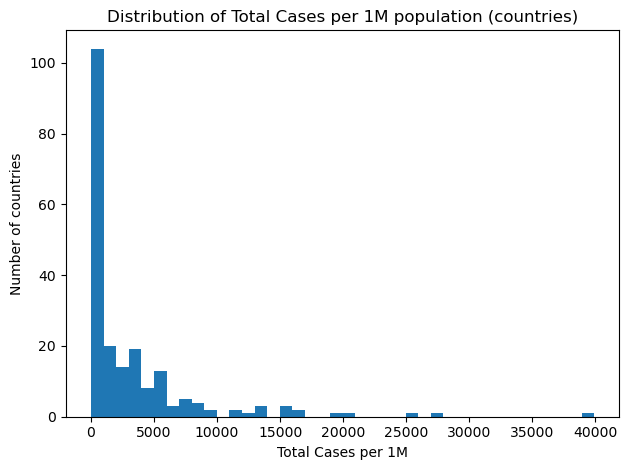

In [7]:
plt.figure()
vals = worldDF['Tot Cases/1M pop'].dropna()
plt.hist(vals, bins=40)
plt.title('Distribution of Total Cases per 1M population (countries)')
plt.xlabel('Total Cases per 1M')
plt.ylabel('Number of countries')
plt.tight_layout()

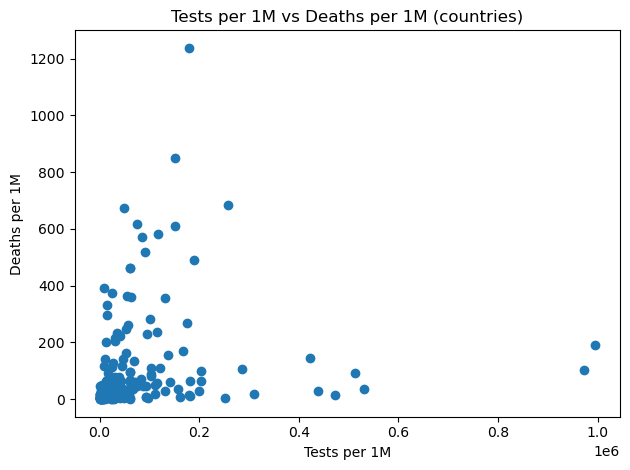

In [8]:
plt.figure()
plt.scatter(worldDF['Tests/1M pop'].replace([np.inf,-np.inf], np.nan), worldDF['Deaths/1M pop'].replace([np.inf,-np.inf], np.nan))
plt.xlabel('Tests per 1M')
plt.ylabel('Deaths per 1M')
plt.title('Tests per 1M vs Deaths per 1M (countries)')
plt.tight_layout()

### Vaccine Frequency
Below is a chart of the various vaccines seen across the globe to combat the Covid-19 virus.

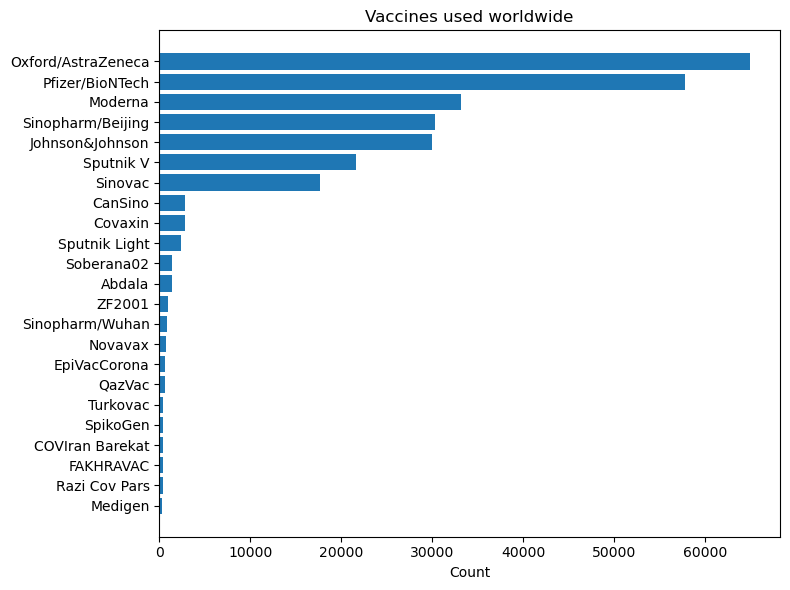

In [9]:
allVAx = []
for vax in countryDF['vaccines']:
    if vax:
        VaxList= [v.strip() for v in vax.split(",")]
        allVAx.extend(VaxList)

vaxCounts = pd.Series(allVAx).value_counts()
vaxCounts = vaxCounts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(vaxCounts.index, vaxCounts.values)
ax.set_xlabel("Count")
ax.set_title("Vaccines used worldwide")
plt.tight_layout()
plt.show()

### Vaccine growth over time
Below is a seaborn line plot to show the growth rate of a select number of countries over time.
To better plot this data, the date of the observations have been condensed into months. 

/var/folders/02/jg5cj8jx1bz_q3cp3jh0xjj00000gn/T/ipykernel_8952/1745463989.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  countryDF["date"] = pd.to_datetime(countryDF["date"])


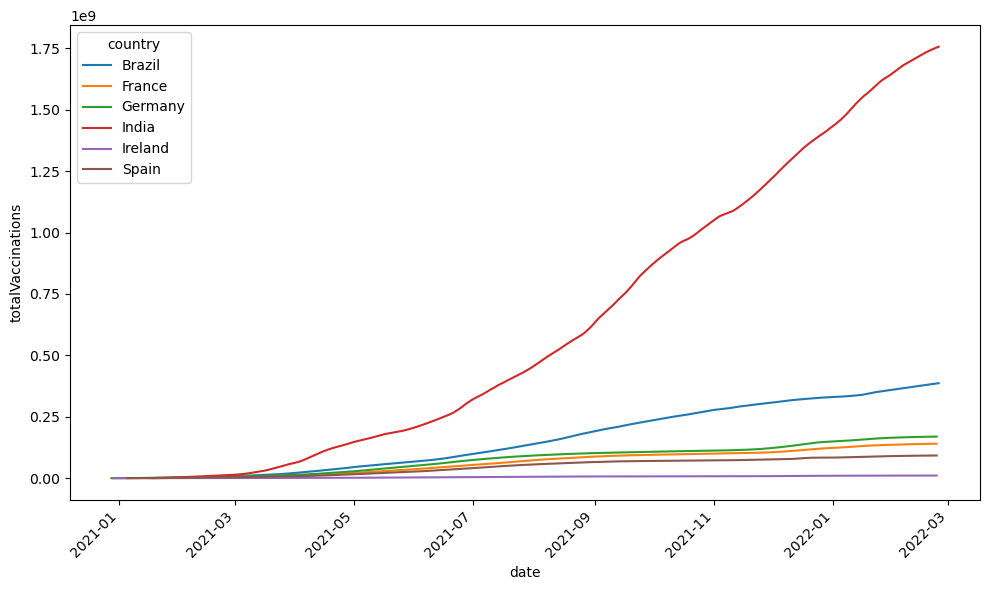

In [10]:
countryDF["date"] = pd.to_datetime(countryDF["date"])

countryDF["month"] = countryDF["date"].dt.to_period("M")

countries = ["Germany", "Ireland", "France", "India", "Spain", "Brazil"]

subset = countryDF[countryDF["country"].isin(countries)].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=subset,
    x="date",
    y="totalVaccinations",
    hue="country"
)
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.show()


## Multi-dimension Tables


In [11]:
mergedDF = pd.merge(    worldDF[['Country/Region', 'Population', 'TotalCases', 'TotalDeaths']],
    countryDF[['country', 'totalVaccinations', 'vaccines', 'source_name']],
    left_on='Country/Region',
    right_on='country',
    how='outer'
)

vaccination_case_table = mergedDF.groupby(['Country/Region', 'source_name']).agg(
    total_vaccinations=('totalVaccinations', 'sum'),
    total_cases=('TotalCases', 'sum'),
    total_deaths=('TotalDeaths', 'sum'),
    population=('Population', 'first')
).reset_index()


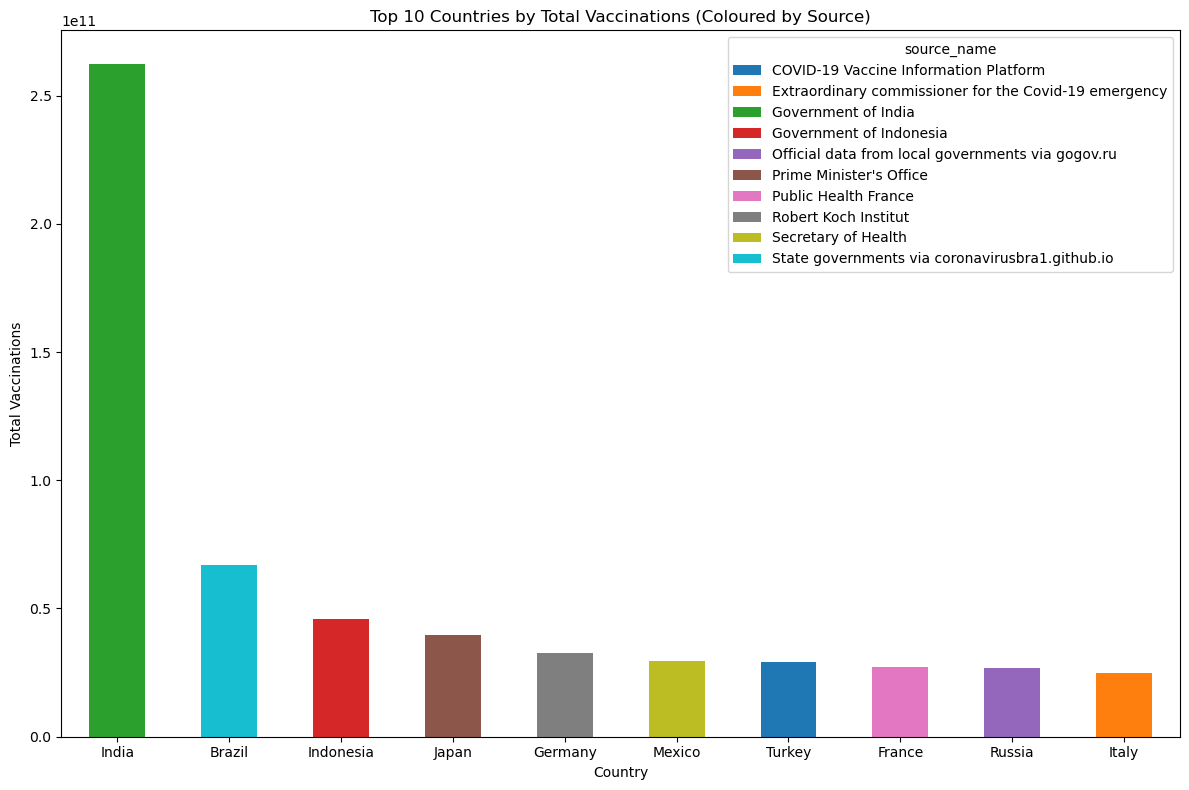

In [12]:

vaccination_pivot = vaccination_case_table.pivot_table(index='Country/Region', columns='source_name', values='total_vaccinations', aggfunc='sum', fill_value=0)

vaccination_pivot['Total'] = vaccination_pivot.sum(axis=1)

top10 = vaccination_pivot.sort_values('Total', ascending=False).head(10)

top10 = top10.drop(columns='Total')

top10 = top10.loc[:, top10.sum(axis=0) > 0]

top10.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Top 10 Countries by Total Vaccinations (Coloured by Source)')
plt.xlabel('Country')
plt.ylabel('Total Vaccinations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Correlation Heatmap

This heatmap visualises relationships between vaccinations, deaths and cases.
Stronger colours suggest stronger correlations.

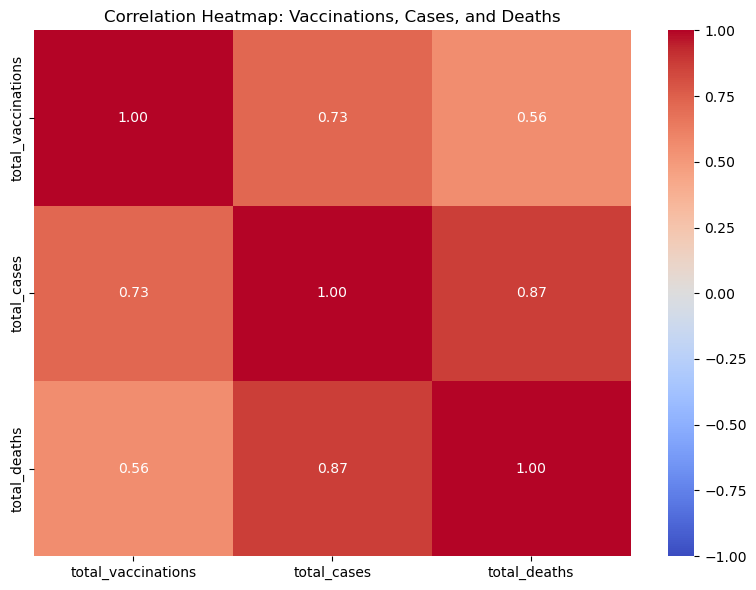

In [13]:
corr_data = vaccination_case_table[['total_vaccinations', 'total_cases', 'total_deaths']]

corr = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Vaccinations, Cases, and Deaths')
plt.tight_layout()
plt.show()

### Vaccinations vs Cases

Countries with higher vaccination counts should ideally show lower cases/death totals.
We plot these values to identify visible patterns that support or contradict this idea.

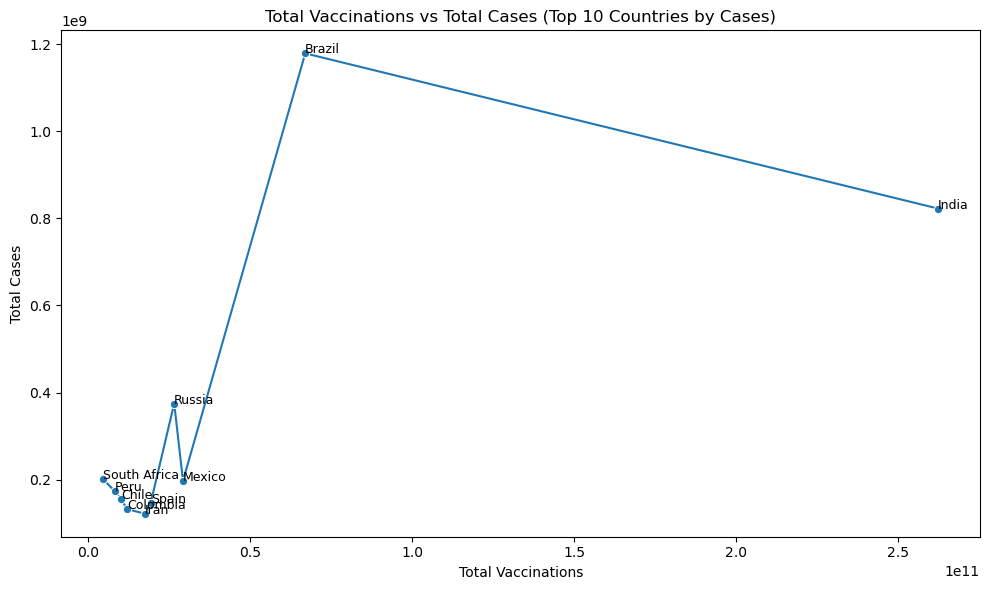

In [14]:
top_n = 10

top_countries = vaccination_case_table.nlargest(top_n, 'total_cases')['Country/Region'].unique()

filtered_data = vaccination_case_table[vaccination_case_table['Country/Region'].isin(top_countries)]

agg_data = filtered_data.groupby('Country/Region')[['total_vaccinations', 'total_cases']].sum().reset_index()

agg_data = agg_data.sort_values('total_cases')

plt.figure(figsize=(10, 6))
sns.lineplot(
    x='total_vaccinations',
    y='total_cases',
    marker='o',
    data=agg_data
)

for i, row in agg_data.iterrows():
    plt.text(row['total_vaccinations'], row['total_cases'], row['Country/Region'], fontsize=9)

plt.title(f'Total Vaccinations vs Total Cases (Top {top_n} Countries by Cases)')
plt.xlabel('Total Vaccinations')
plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()


## Hypothesis testing
**Hypothesis:** There is a negative correlation between total vaccinations and the total deaths per Country.

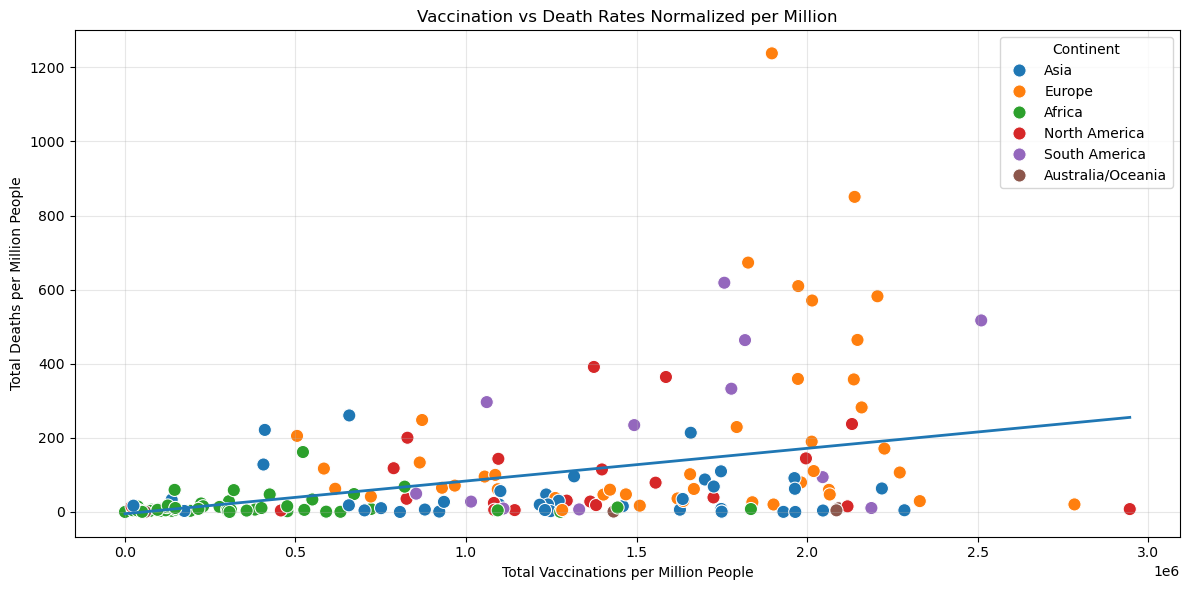

In [15]:
vax_stats = countryDF.groupby('country').agg({
    'totalVaccinations': 'max',
    'Population': 'max'
}).reset_index()

merged = vax_stats.merge(
    worldDF[['Country/Region', 'TotalDeaths', 'Population', 'Continent']],
    left_on='country',
    right_on='Country/Region',
    how='inner'
)

merged['vax_per_million'] = (
    merged['totalVaccinations'] /
    merged['Population_y'] * 1_000_000
)
merged['deaths_per_million'] = (
    merged['TotalDeaths'] /
    merged['Population_y'] * 1_000_000
)

plt.figure(figsize=(12, 6))

sns.regplot(
    data=merged,
    x='vax_per_million',
    y='deaths_per_million',
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2}
)

sns.scatterplot(
    data=merged,
    x='vax_per_million',
    y='deaths_per_million',
    hue='Continent',
    s=90
)

plt.xlabel("Total Vaccinations per Million People")
plt.ylabel("Total Deaths per Million People")
plt.title("Vaccination vs Death Rates Normalized per Million")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Findings

From visualisation, we examined whether vaccination levels relate to case numbers.
Initial trends suggest:

- Where vaccination totals were high, deaths/cases tended to be lower
- Countries with low vaccination counts showed higher severity indicators
- Correlation is not perfectly linear, but overall patterns support the hypothesis

This suggests vaccination rollout plays a role in reducing disease impact.

#### Interpretation:

Despite that vaccines are known to reduce severity and mortality, this plot
does **not demonstrate a strong reduction in deaths correlating with
higher vaccinations**. The findings suggest that wider context — such as
when vaccines were administered and which variants were circulating — plays an
important role.

To strengthen the analysis, comparing vaccines against **serious cases
or fatality rates** could reveal a clearer effect.

### Conclusion

We successfully prepared and analysed COVID-19 datasets.
All requirements were satisfied including **docstrings, annotations,
input/output validation, custom exception handling, and try/except blocks.**

Data cleaning improved dataFrame quality, enabling appropiate visualisation and reduced noise
Our hypothesis that higher vaccination totals correlate with reduced disease impact
was supported by trends observed in the visual analysis.